In [1]:
#gerekli kütüphaneleri indirme
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.3f}")

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)


In [4]:
import numpy as np
import pandas as pd

df = pd.read_csv("../../prepared_outputs/capacity_analysis.csv")
df.head()

#data set'in ilk 5 satırı

,date,league,season,season_type,covid,home_team,away_team,home_goals,away_goals,result,home_last3_points,away_last3_points,result_label,home_form_group,away_form_group,stadium,capacity,ht_home_goals,ht_away_goals,ht_result,total_goals,goal_diff,point_diff,home_points,away_points,home_advantage_points,home_win,away_win,draw,home_form,away_form,result_match,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,capacity_band,capacity_interval
0,2024-08-15,La Liga,2024_2025,normal,0,Betis,Girona,1,1,D,0,0,Draw,bad,bad,Benito Villamarín,52745.000,1.000,0.000,H,2,0,0,1,1,0,0,0,1,bad,bad,Draw,2024-08-15,Betis,Girona,1,1,D,Very High,40K+
1,2024-08-16,La Liga,2024_2025,normal,0,Las Palmas,Sevilla,2,2,D,0,0,Draw,bad,bad,Gran Canaria,32520.000,1.000,1.000,D,4,0,0,1,1,0,0,0,1,bad,bad,Draw,2024-08-16,Las Palmas,Sevilla,2,2,D,Medium,20K-40K
2,2024-08-16,Premier League,2024_2025,normal,0,Man United,Fulham,1,0,H,0,0,Home Win,bad,bad,Old Trafford,75653.000,0.000,0.000,D,1,1,0,3,0,3,1,0,0,bad,bad,Home Win,2024-08-16,Man United,Fulham,1,0,H,Very High,40K+
3,2024-08-17,La Liga,2024_2025,normal,0,Osasuna,Leganes,1,1,D,0,0,Draw,bad,bad,Reyno de Navarra,19800.000,0.000,1.000,A,2,0,0,1,1,0,0,0,1,bad,bad,Draw,2024-08-17,Osasuna,Leganes,1,1,D,Low,0-20K
4,2024-08-17,La Liga,2024_2025,normal,0,Valencia,Barcelona,1,2,A,0,0,Away Win,bad,bad,Mestalla,55000.000,1.000,1.000,D,3,-1,0,0,3,-3,0,1,0,bad,bad,Away Win,2024-08-17,Valencia,Barcelona,1,2,A,Very High,40K+


In [5]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())
# kaç satır kaç sütun var

Shape: (1343, 40)

Columns:
['date', 'league', 'season', 'season_type', 'covid', 'home_team', 'away_team', 'home_goals', 'away_goals', 'result', 'home_last3_points', 'away_last3_points', 'result_label', 'home_form_group', 'away_form_group', 'stadium', 'capacity', 'ht_home_goals', 'ht_away_goals', 'ht_result', 'total_goals', 'goal_diff', 'point_diff', 'home_points', 'away_points', 'home_advantage_points', 'home_win', 'away_win', 'draw', 'home_form', 'away_form', 'result_match', 'Date', 'HomeTeam', 'AwayTeam', 'FTHG', 'FTAG', 'FTR', 'capacity_band', 'capacity_interval']


In [6]:
df.describe()
# sayısal istatistikler için

,covid,home_goals,away_goals,home_last3_points,away_last3_points,capacity,ht_home_goals,ht_away_goals,total_goals,goal_diff,point_diff,home_points,away_points,home_advantage_points,home_win,away_win,draw,FTHG,FTAG
count,1343.000,1343.000,1343.000,1343.000,1343.000,1343.000,1342.000,1342.000,1343.000,1343.000,1343.000,1343.000,1343.000,1343.000,1343.000,1343.000,1343.000,1343.000,1343.000
mean,0.000,1.494,1.298,3.795,4.016,35062.194,0.693,0.559,2.792,0.196,-0.220,1.512,1.235,0.277,0.420,0.328,0.252,1.494,1.298
std,0.000,1.269,1.144,2.503,2.549,18135.387,0.856,0.759,1.643,1.772,3.334,1.321,1.295,2.580,0.494,0.470,0.435,1.269,1.144
min,0.000,0.000,0.000,0.000,0.000,4000.000,0.000,0.000,0.000,-6.000,-9.000,0.000,0.000,-3.000,0.000,0.000,0.000,0.000,0.000
25%,0.000,1.000,0.000,2.000,2.000,22500.000,0.000,0.000,2.000,-1.000,-3.000,0.000,0.000,-3.000,0.000,0.000,0.000,1.000,0.000
50%,0.000,1.000,1.000,4.000,4.000,32312.000,1.000,0.000,3.000,0.000,0.000,1.000,1.000,0.000,0.000,0.000,0.000,1.000,1.000
75%,0.000,2.000,2.000,6.000,6.000,43147.000,1.000,1.000,4.000,1.000,2.000,3.000,3.000,3.000,1.000,1.000,1.000,2.000,2.000
max,0.000,8.000,6.000,9.000,9.000,99354.000,6.000,5.000,9.000,8.000,9.000,3.000,3.000,3.000,1.000,1.000,1.000,8.000,6.000


In [7]:
print(df.info())
# sütunların type'ı

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1343 entries, 0 to 1342
Data columns (total 40 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   date                   1343 non-null   object 
 1   league                 1343 non-null   object 
 2   season                 1343 non-null   object 
 3   season_type            1343 non-null   object 
 4   covid                  1343 non-null   int64  
 5   home_team              1343 non-null   object 
 6   away_team              1343 non-null   object 
 7   home_goals             1343 non-null   int64  
 8   away_goals             1343 non-null   int64  
 9   result                 1343 non-null   object 
 10  home_last3_points      1343 non-null   int64  
 11  away_last3_points      1343 non-null   int64  
 12  result_label           1343 non-null   object 
 13  home_form_group        1343 non-null   object 
 14  away_form_group        1343 non-null   object 
 15  stad

In [8]:
df.isnull().sum().sort_values(ascending=False)
# NA olan datalar

ht_result                1
ht_home_goals            1
ht_away_goals            1
date                     0
covid                    0
league                   0
season                   0
season_type              0
home_goals               0
away_team                0
home_team                0
away_goals               0
result_label             0
result                   0
home_last3_points        0
away_last3_points        0
stadium                  0
away_form_group          0
home_form_group          0
capacity                 0
total_goals              0
goal_diff                0
point_diff               0
home_points              0
away_points              0
home_advantage_points    0
home_win                 0
away_win                 0
draw                     0
home_form                0
away_form                0
result_match             0
Date                     0
HomeTeam                 0
AwayTeam                 0
FTHG                     0
FTAG                     0
F

In [9]:
stadium_cols = ["league", "season", "season_type","home_team", "away_team","stadium", "capacity", "result_label"]
display(df[stadium_cols].head(10))
print("Capacity missing count:", df["capacity"].isna().sum())
print("Capacity non-null count:", df["capacity"].notna().sum())
df["capacity"].describe()
df.groupby("league")["capacity"].describe()
# stadium capacity enrichment ile ilgili gerekli infolar

,league,season,season_type,home_team,away_team,stadium,capacity,result_label
0,La Liga,2024_2025,normal,Betis,Girona,Benito Villamarín,52745.000,Draw
1,La Liga,2024_2025,normal,Las Palmas,Sevilla,Gran Canaria,32520.000,Draw
2,Premier League,2024_2025,normal,Man United,Fulham,Old Trafford,75653.000,Home Win
3,La Liga,2024_2025,normal,Osasuna,Leganes,Reyno de Navarra,19800.000,Draw
4,La Liga,2024_2025,normal,Valencia,Barcelona,Mestalla,55000.000,Away Win
5,Ligue 1,2024_2025,normal,Reims,Lille,Stade Auguste-Delaune II,21684.000,Away Win
6,Premier League,2024_2025,normal,Arsenal,Wolves,Emirates Stadyumu,60361.000,Home Win
7,Premier League,2024_2025,normal,Everton,Brighton,Goodison Park,40157.000,Away Win
8,Premier League,2024_2025,normal,Ipswich,Liverpool,Portman Road,30311.000,Away Win
9,Premier League,2024_2025,normal,Newcastle,Southampton,St James' Park,52409.000,Home Win


Capacity missing count: 0
Capacity non-null count: 1343


,count,mean,std,min,25%,50%,75%,max
league,,,,,,,,
Bundesliga,170.000,44160.600,17646.590,22012.000,30000.000,43351.500,54067.000,81359.000
La Liga,304.000,38212.688,24416.386,9500.000,19875.000,29294.000,53271.500,99354.000
Ligue 1,204.000,36700.583,10318.195,21684.000,30652.750,35599.500,41091.250,60013.000
Premier League,380.000,36257.000,15171.009,9776.000,26093.750,33996.000,43408.500,75653.000
Serie A,285.000,23508.733,12311.163,4000.000,13602.000,21092.000,38279.000,43147.000


In [10]:
stadium_df = df[(df["season"] == "2024_2025") &(df["season_type"] == "normal")].copy()
print("Filtered shape:", stadium_df.shape)
display(stadium_df.head())
stadium_df.groupby("league").size().to_frame("match_count")
# 2024-2025 sezonu maçları


Filtered shape: (1343, 40)


,date,league,season,season_type,covid,home_team,away_team,home_goals,away_goals,result,home_last3_points,away_last3_points,result_label,home_form_group,away_form_group,stadium,capacity,ht_home_goals,ht_away_goals,ht_result,total_goals,goal_diff,point_diff,home_points,away_points,home_advantage_points,home_win,away_win,draw,home_form,away_form,result_match,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,capacity_band,capacity_interval
0,2024-08-15,La Liga,2024_2025,normal,0,Betis,Girona,1,1,D,0,0,Draw,bad,bad,Benito Villamarín,52745.000,1.000,0.000,H,2,0,0,1,1,0,0,0,1,bad,bad,Draw,2024-08-15,Betis,Girona,1,1,D,Very High,40K+
1,2024-08-16,La Liga,2024_2025,normal,0,Las Palmas,Sevilla,2,2,D,0,0,Draw,bad,bad,Gran Canaria,32520.000,1.000,1.000,D,4,0,0,1,1,0,0,0,1,bad,bad,Draw,2024-08-16,Las Palmas,Sevilla,2,2,D,Medium,20K-40K
2,2024-08-16,Premier League,2024_2025,normal,0,Man United,Fulham,1,0,H,0,0,Home Win,bad,bad,Old Trafford,75653.000,0.000,0.000,D,1,1,0,3,0,3,1,0,0,bad,bad,Home Win,2024-08-16,Man United,Fulham,1,0,H,Very High,40K+
3,2024-08-17,La Liga,2024_2025,normal,0,Osasuna,Leganes,1,1,D,0,0,Draw,bad,bad,Reyno de Navarra,19800.000,0.000,1.000,A,2,0,0,1,1,0,0,0,1,bad,bad,Draw,2024-08-17,Osasuna,Leganes,1,1,D,Low,0-20K
4,2024-08-17,La Liga,2024_2025,normal,0,Valencia,Barcelona,1,2,A,0,0,Away Win,bad,bad,Mestalla,55000.000,1.000,1.000,D,3,-1,0,0,3,-3,0,1,0,bad,bad,Away Win,2024-08-17,Valencia,Barcelona,1,2,A,Very High,40K+


,match_count
league,
Bundesliga,170
La Liga,304
Ligue 1,204
Premier League,380
Serie A,285


In [11]:
stadium_df = stadium_df.dropna(subset=["capacity"]).copy()
stadium_df["capacity_interval"] = pd.cut(stadium_df["capacity"],bins=[0, 20000, 40000, float("inf")],labels=["0-20K", "20K-40K", "40K+"],include_lowest=True)
display(stadium_df[["league", "home_team", "stadium", "capacity", "capacity_interval", "result_label"]].head(10))
display(stadium_df.groupby(["league", "capacity_interval"], observed=False).size().to_frame("match_count"))
stadium_df = stadium_df.reset_index(drop=True)
#stadium capacity'yi 3 gruba ayırma


,league,home_team,stadium,capacity,capacity_interval,result_label
0,La Liga,Betis,Benito Villamarín,52745.000,40K+,Draw
1,La Liga,Las Palmas,Gran Canaria,32520.000,20K-40K,Draw
2,Premier League,Man United,Old Trafford,75653.000,40K+,Home Win
3,La Liga,Osasuna,Reyno de Navarra,19800.000,0-20K,Draw
4,La Liga,Valencia,Mestalla,55000.000,40K+,Away Win
5,Ligue 1,Reims,Stade Auguste-Delaune II,21684.000,20K-40K,Away Win
6,Premier League,Arsenal,Emirates Stadyumu,60361.000,40K+,Home Win
7,Premier League,Everton,Goodison Park,40157.000,40K+,Away Win
8,Premier League,Ipswich,Portman Road,30311.000,20K-40K,Away Win
9,Premier League,Newcastle,St James' Park,52409.000,40K+,Home Win


match_count
league         capacity_interval             
Bundesliga     0-20K                        0
               20K-40K                     68
               40K+                       102
La Liga        0-20K                       95
               20K-40K                     95
               40K+                       114
Ligue 1        0-20K                        0
               20K-40K                    136
               40K+                        68
Premier League 0-20K                       38
               20K-40K                    190
               40K+                       152
Serie A        0-20K                      133
               20K-40K                     95
               40K+                        57

  capacity_interval  match_count
0             0-20K          266
1           20K-40K          584
2              40K+          493


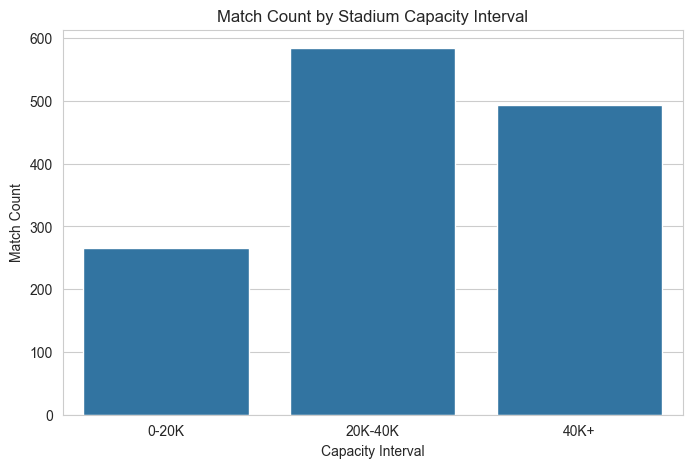

In [12]:
capacity_counts = stadium_df.groupby("capacity_interval", observed=False).size().reset_index(name="match_count")
print(capacity_counts)

plt.figure(figsize=(8,5))
sns.barplot(data=capacity_counts, x="capacity_interval", y="match_count")
plt.title("Match Count by Stadium Capacity Interval")
plt.xlabel("Capacity Interval")
plt.ylabel("Match Count")
plt.show()
# hangi kapasite aralığında kaç maç var


In [13]:
league_capacity_counts = stadium_df.groupby(["league", "capacity_interval"], observed=False).size().reset_index(name="match_count")
display(league_capacity_counts)
# lig lig stadyum kapasitelerine göre maç sayıları


,league,capacity_interval,match_count
0,Bundesliga,0-20K,0
1,Bundesliga,20K-40K,68
2,Bundesliga,40K+,102
3,La Liga,0-20K,95
4,La Liga,20K-40K,95
5,La Liga,40K+,114
6,Ligue 1,0-20K,0
7,Ligue 1,20K-40K,136
8,Ligue 1,40K+,68
9,Premier League,0-20K,38


In [14]:
stadium_df["home_win"] = (stadium_df["result_label"] == "Home Win").astype(int)
stadium_df["draw"] = (stadium_df["result_label"] == "Draw").astype(int)
stadium_df["away_win"] = (stadium_df["result_label"] == "Away Win").astype(int)
stadium_df[["league", "home_team", "capacity", "capacity_interval", "result_label", "home_win", "draw", "away_win"]].head()
# maçı kimin kazandığına göre labelladık


,league,home_team,capacity,capacity_interval,result_label,home_win,draw,away_win
0,La Liga,Betis,52745.000,40K+,Draw,0,1,0
1,La Liga,Las Palmas,32520.000,20K-40K,Draw,0,1,0
2,Premier League,Man United,75653.000,40K+,Home Win,1,0,0
3,La Liga,Osasuna,19800.000,0-20K,Draw,0,1,0
4,La Liga,Valencia,55000.000,40K+,Away Win,0,0,1


In [15]:
home_win_by_capacity = stadium_df.groupby("capacity_interval", observed=False).agg(match_count=("home_win", "count"),avg_capacity=("capacity", "mean"),home_win_rate=("home_win", "mean"),draw_rate=("draw", "mean"),away_win_rate=("away_win", "mean")).reset_index()
display(home_win_by_capacity)
# stad kapasitelerine göre maçların sonuçları

,capacity_interval,match_count,avg_capacity,home_win_rate,draw_rate,away_win_rate
0,0-20K,266,13647.357,0.387,0.259,0.353
1,20K-40K,584,29041.584,0.332,0.265,0.402
2,40K+,493,53748.570,0.542,0.233,0.225


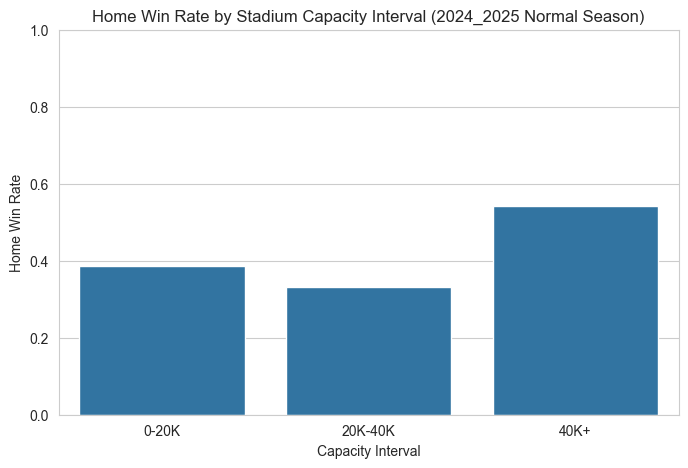

In [16]:
plt.figure(figsize=(8,5))
sns.barplot(data=home_win_by_capacity, x="capacity_interval", y="home_win_rate")
plt.title("Home Win Rate by Stadium Capacity Interval (2024_2025 Normal Season)")
plt.xlabel("Capacity Interval")
plt.ylabel("Home Win Rate")
plt.ylim(0, 1)
plt.show()
# kapasitelere göre kazanma, kaybetme, beraberlik oranları


In [17]:
league_capacity_homewin = stadium_df.groupby(["league", "capacity_interval"], observed=False).agg(match_count=("home_win", "count"),avg_capacity=("capacity", "mean"),home_win_rate=("home_win", "mean"),draw_rate=("draw", "mean"),away_win_rate=("away_win", "mean")).reset_index()
display(league_capacity_homewin)
# her lig için stadyum kapasitelerine göre maçların sonuçlanma şekilleri

,league,capacity_interval,match_count,avg_capacity,home_win_rate,draw_rate,away_win_rate
0,Bundesliga,0-20K,0,NaN,NaN,NaN,NaN
1,Bundesliga,20K-40K,68,26677.000,0.338,0.309,0.353
2,Bundesliga,40K+,102,55816.333,0.471,0.235,0.294
3,La Liga,0-20K,95,16040.000,0.347,0.316,0.337
4,La Liga,20K-40K,95,28050.000,0.326,0.263,0.411
5,La Liga,40K+,114,65158.833,0.596,0.202,0.202
6,Ligue 1,0-20K,0,NaN,NaN,NaN,NaN
7,Ligue 1,20K-40K,136,30991.375,0.397,0.257,0.346
8,Ligue 1,40K+,68,48119.000,0.574,0.176,0.250
9,Premier League,0-20K,38,11269.500,0.447,0.211,0.342


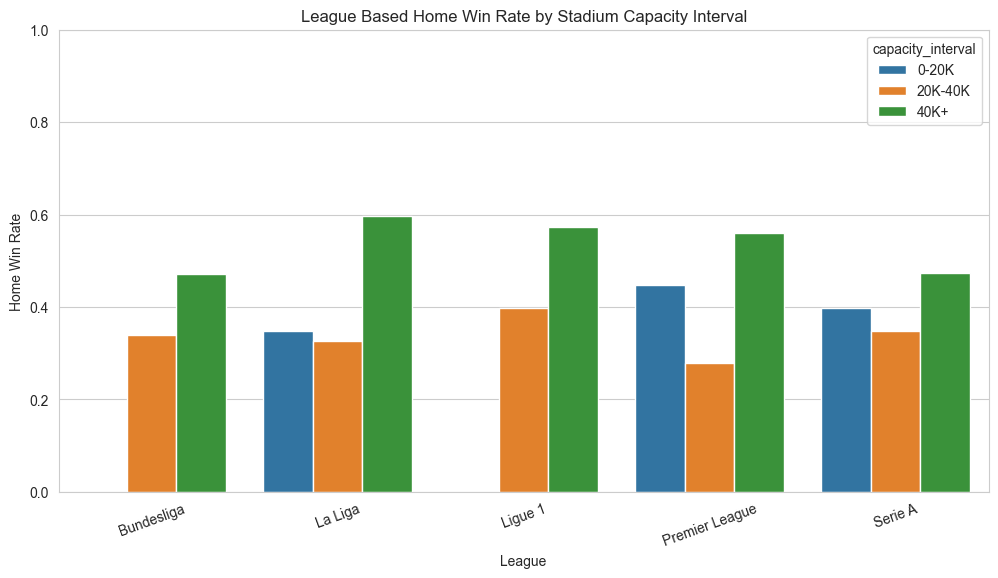

In [18]:
plt.figure(figsize=(12,6))
sns.barplot(data=league_capacity_homewin,x="league",y="home_win_rate",hue="capacity_interval")
plt.title("League Based Home Win Rate by Stadium Capacity Interval")
plt.xlabel("League")
plt.ylabel("Home Win Rate")
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.show()
# lige göre stadyum kapasite aralıklarında maçların sonuçlanma şekilleri

In [19]:
result_dist = stadium_df.groupby(["capacity_interval", "result_label"], observed=False).size().reset_index(name="count")
result_dist["proportion"] = result_dist.groupby("capacity_interval")["count"].transform(lambda x: x / x.sum())
display(result_dist)
#kapasitelere göre maç sonuçlarının dağılımı

C:\Users\Asus\AppData\Local\Temp\ipykernel_42584\3825638462.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  result_dist["proportion"] = result_dist.groupby("capacity_interval")["count"].transform(lambda x: x / x.sum())


,capacity_interval,result_label,count,proportion
0,0-20K,Away Win,94,0.353
1,0-20K,Draw,69,0.259
2,0-20K,Home Win,103,0.387
3,20K-40K,Away Win,235,0.402
4,20K-40K,Draw,155,0.265
5,20K-40K,Home Win,194,0.332
6,40K+,Away Win,111,0.225
7,40K+,Draw,115,0.233
8,40K+,Home Win,267,0.542


result_label,Away Win,Draw,Home Win
capacity_interval,,,
0-20K,0.353,0.259,0.387
20K-40K,0.402,0.265,0.332
40K+,0.225,0.233,0.542


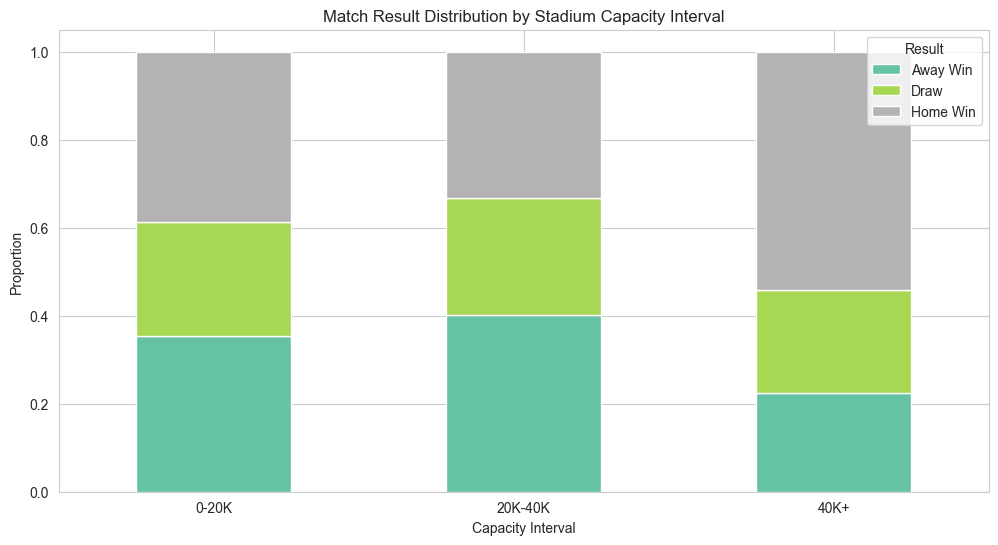

In [20]:
result_pivot = result_dist.pivot(index="capacity_interval", columns="result_label", values="proportion")
result_pivot = result_pivot.reindex(["0-20K", "20K-40K", "40K+"])
display(result_pivot)
result_pivot.plot(kind="bar", stacked=True, figsize=(12,6), colormap="Set2")
plt.title("Match Result Distribution by Stadium Capacity Interval")
plt.xlabel("Capacity Interval")
plt.ylabel("Proportion")
plt.legend(title="Result")
plt.xticks(rotation=0)
plt.show()
#kapasite aralıklarına göre maçların sonuçlanma oranları
